In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [2]:
cifar10_test_acc = []
cifar10_flops = []
cifar10_paras = []

cifar100_test_acc = []
cifar100_flops = []
cifar100_paras = []

ImageNet16_120_test_acc = []
ImageNet16_120_flops = []
ImageNet16_120_paras = []

In [3]:
with open('all_model.txt') as f:
    for line in f:
        line = line.rstrip()
        # print(line[0:19])
        if line[0:20] == 'cifar10        FLOP=':
            cifar10_flops.append(float(line[20:25]))
            cifar10_paras.append(float(line[37:41]))
        elif line[0:20] == 'cifar10        train':
            cifar10_test_acc.append(float(line[-7:-2]))
        
        elif line[0:20] == 'cifar100       FLOP=':
            cifar100_flops.append(float(line[20:25]))
            cifar100_paras.append(float(line[37:41]))
        elif line[0:20] == 'cifar100       train':
            cifar100_test_acc.append(float(line[-7:-2]))

        elif line[0:20] == 'ImageNet16-120 FLOP=':
            ImageNet16_120_flops.append(float(line[21:25]))
            ImageNet16_120_paras.append(float(line[37:41]))
        elif line[0:20] == 'ImageNet16-120 train':
            ImageNet16_120_test_acc.append(float(line[-7:-2]))


In [4]:
len(cifar100_flops)

15625

In [ ]:
len(ImageNet16_120_test_acc)

15625

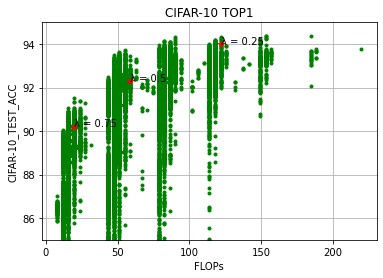

In [ ]:
plt.plot(cifar10_flops, cifar10_test_acc, 'g.')
plt.xlabel('FLOPs')
plt.ylabel('CIFAR-10_TEST_ACC')
plt.title('CIFAR-10 TOP1')
plt.plot(121.82, 93.99, 'r*')
plt.text(121.82, 93.99,'λ = 0.25')
plt.plot(58.9, 92.31, 'r*')
plt.text(58.9, 92.31,'λ = 0.5')
plt.plot(19.58, 90.21, 'r*')
plt.text(19.58, 90.21,'λ = 0.75')
plt.grid(True)
plt.ylim([85, 95])
plt.savefig("myimg_1.svg")


In [ ]:
cifar10_flops_normalized = preprocessing.normalize(np.array(cifar10_flops).reshape(1, -1))
cifar100_flops_normalized = preprocessing.normalize(np.array(cifar100_flops).reshape(1, -1))
ImageNet16_120_flops_normalized = preprocessing.normalize(np.array(ImageNet16_120_flops).reshape(1, -1))
Normlized_overall_flops = np.add(cifar10_flops_normalized, cifar100_flops_normalized, ImageNet16_120_flops_normalized)


In [ ]:
Normlized_overall_flops.shape

(1, 15625)

In [ ]:
cifar10_test_acc_normalized = preprocessing.normalize(np.array(cifar10_test_acc).reshape(1, -1))
cifar100_test_acc_normalized = preprocessing.normalize(np.array(cifar100_test_acc).reshape(1, -1))
ImageNet16_120_test_acc_normalized = preprocessing.normalize(np.array(ImageNet16_120_test_acc).reshape(1, -1))
Normlized_overall_test_acc = np.add(cifar10_test_acc_normalized, cifar100_test_acc_normalized, ImageNet16_120_test_acc_normalized)

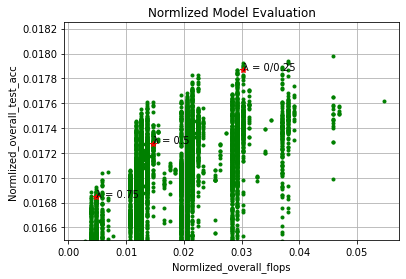

In [ ]:
plt.plot(Normlized_overall_flops, Normlized_overall_test_acc, 'g.')
plt.xlabel('Normlized_overall_flops')
plt.ylabel('Normlized_overall_test_acc')
plt.title('Normlized Model Evaluation')
plt.plot(Normlized_overall_flops[:,857], Normlized_overall_test_acc[:,857], 'r*')
plt.text(Normlized_overall_flops[:,857], Normlized_overall_test_acc[:,857],'λ = 0/0.25')

plt.plot(Normlized_overall_flops[:,2564], Normlized_overall_test_acc[:,2564], 'r*')
plt.text(Normlized_overall_flops[:,2564], Normlized_overall_test_acc[:,2564],'λ = 0.5')

plt.plot(Normlized_overall_flops[:,485], Normlized_overall_test_acc[:,485], 'r*')
plt.text(Normlized_overall_flops[:,485], Normlized_overall_test_acc[:,485],'λ = 0.75')
plt.grid(True)
plt.ylim([0.0155, 0.01825])
plt.savefig("Normlized_Model_Evaluation_zoom_in.svg")

In [2]:
OPS = ['input', 'none', 'skip_connect', 'nor_conv_3x3', 'nor_conv_1x1',  'avg_pool_3x3', 'output']

In [30]:
cifar_10_dic = dict(zip(range(len(cifar10_test_acc)), cifar10_test_acc))
data_all = np.load('combined.npy')
cifar_10_pridict = data_all[:,1]
cifar_10_dic_pridict = dict(zip(range(len(cifar10_test_acc)), cifar_10_pridict))

In [31]:
lists = sorted(cifar_10_dic.items(), key=lambda kv: kv[1], reverse=False) # sorted by value, return a list of tuples
lists_pridict = sorted(cifar_10_dic_pridict.items(), key=lambda kv: kv[1], reverse=False) # sorted by value, return a list of tuples
x, y = zip(*lists) # unpack a list of pairs into two tuples
x_pridict, y_pridict = zip(*lists_pridict) # unpack a list of pairs into two tuples

In [32]:
print(y)
y_rank = [0] * len(y)
for i, item in enumerate(range(len(y))):
    y_rank[item] = i
print(y_rank)


print(y_pridict)
y_rank_pridict = [0] * len(y_pridict)
for i, item in enumerate(range(len(y_pridict))):
    y_rank_pridict[item] = i
print(y_rank_pridict)

(10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.

In [33]:
cifar_10_dic_1 = dict(zip(x, y_rank))
lists_1 = sorted(cifar_10_dic_1.items()) # sorted by key, return a list of tuples
x_1, y_1 = zip(*lists_1) # unpack a list of pairs into two tuples
print(y_1)


cifar_10_dic_pridict_1 = dict(zip(x_pridict, y_rank_pridict))
lists_pridict_1 = sorted(cifar_10_dic_pridict_1.items()) # sorted by key, return a list of tuples
x_pridict_1, y_pridict_1 = zip(*lists_pridict_1) # unpack a list of pairs into two tuples
print(y_pridict_1)


(2595, 15361, 2553, 3148, 4247, 8491, 12986, 10725, 11311, 2922, 0, 9550, 1, 10081, 10832, 456, 14437, 6106, 9306, 4854, 7067, 11884, 6833, 7235, 3574, 3050, 7032, 7367, 2811, 5140, 10514, 8104, 12554, 10382, 9627, 9209, 8463, 6468, 11952, 6052, 964, 4754, 15286, 9856, 1594, 6335, 8369, 8441, 3066, 9283, 14503, 4360, 14842, 369, 8999, 3318, 15055, 1264, 491, 5209, 5766, 4979, 12154, 12682, 13586, 15175, 1122, 15019, 9566, 15413, 10679, 7704, 2923, 6226, 2, 745, 3686, 14804, 10472, 10515, 11616, 15618, 11569, 2483, 9376, 8224, 12616, 1424, 4515, 10947, 7115, 6682, 8856, 8678, 3975, 592, 7177, 4876, 5639, 15340, 11480, 4238, 11801, 12929, 3, 4, 1008, 3931, 5, 14675, 7922, 15391, 10680, 3722, 7299, 7578, 11885, 12341, 1569, 11709, 6, 10251, 6848, 2106, 11109, 6787, 2237, 4855, 12155, 15258, 11416, 2943, 10789, 14785, 7068, 9940, 11525, 14622, 15377, 7300, 11261, 7236, 12342, 8567, 3307, 6998, 2679, 14330, 11481, 7211, 4550, 1380, 11417, 14765, 8761, 3560, 3561, 357, 13531, 6553, 2924, 812

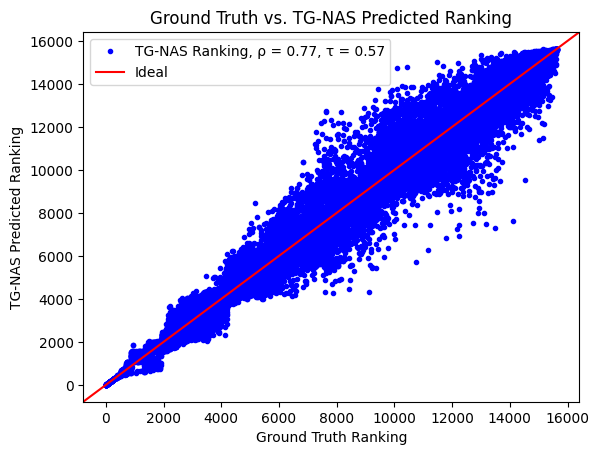

In [48]:
plt.plot(y_1, y_pridict_1,'b.', label='TG-NAS Ranking, ρ = 0.77, τ = 0.57')
plt.axline((0, 0), slope=1, color = 'red', label='Ideal')
plt.xlabel('Ground Truth Ranking')
plt.ylabel('TG-NAS Predicted Ranking')
plt.title('Ground Truth vs. TG-NAS Predicted Ranking')
plt.legend()
plt.savefig("Ground Truth vs. TG-NAS Predicted Ranking'.svg")


In [ ]:
plt.plot(cifar10_flops, cifar10_test_acc, 'g.')

In [8]:
def transform_matrix(genotype):
    normal = genotype
    node_num = len(normal)+3
    adj = np.zeros((node_num, node_num))
    ops = np.zeros((node_num, len(OPS)))
    for i in range(len(normal)):
        op, connect = normal[i]
        if connect == 0 or connect==1:
            adj[connect][i+2] = 1
        else:
            adj[(connect-2)*2+2][i+2] = 1
            adj[(connect-2)*2+3][i+2] = 1
        ops[i+2][OPS.index(op)] = 1
    adj[4:-1, -1] = 1
    ops[0:2, 0] = 1
    ops[-1][-1] = 1
    return adj, ops

def transform_matrix_1(genotype):
    normal = genotype
    node_num = len(normal)+2
    adj = np.zeros((node_num, node_num))
    ops = np.zeros((node_num, len(OPS)))
    for i in range(len(normal)):
        op, connect = normal[i]
        if connect == 0 or connect==1:
            adj[connect][i+1] = 1
        else:
            adj[(connect-2)*2+2][i+1] = 1
            adj[(connect-2)*2+3][i+1] = 1
        ops[i+1][OPS.index(op)] = 1
    adj[4:-1, -1] = 1
    ops[0:1, 0] = 1
    ops[-1][-1] = 1
    return adj, ops

def transform_matrix_2(genotype, isseleted):
    normal = genotype
    node_num = len(normal)+2
    adj = np.zeros((node_num, node_num))
    ops = np.zeros((node_num, len(OPS)))
    for i in range(len(normal)):
        op, connect = normal[i]
        if connect == 0 or connect==1:
            adj[connect][i+1] = 1
        else:
            adj[(connect-2)*2+2][i+1] = 1
            adj[(connect-2)*2+3][i+1] = 1
        ops[i+1][OPS.index(op)] = 1
    adj[4:-1, -1] = 1
    ops[0:1, 0] = 1
    ops[-1][-1] = 1
    if isseleted:
        ops = ops[:,[0,3,4,5,6]]
    return adj, ops

In [5]:
genotype = [
    ('skip_connect', 0),
    ('nor_conv_1x1', 0),
    ('skip_connect', 1),
    ('nor_conv_3x3', 0),
    ('avg_pool_3x3', 1),
    ('nor_conv_1x1', 2),
    ]

In [6]:
acc_all = []
with open('all_model.txt') as f:
    for line in f:
        line = line.rstrip()
        # print(line[0:7])
        if line[0:22] == 'cifar10        train :':
            acc = float(line[-7:-2])
            acc_all.append(acc)
print(len(acc_all))            

15625


In [9]:
i = -1
data_all_list = []
data_selected_list = []
with open('all_model.txt') as f:
    for line in f:
        if line.strip() == "":
            i+=1
        line = line.rstrip()
        if line[0:7] == 'arch : ':
            select = True
            geno = line[7:]
            geno_list = geno.split('+')
            genotype = []
            for a in geno_list:
                a = a[1:-1]
                b = a.split('|')
                for c in b:
                    ops = c[0:-2]
                    connect = c[-1:]
                    genotype.append((ops, int(connect)))
                    if ops == 'skip_connect' or ops == 'none':
                        select = False
            # print(genotype)
            # print(i)
            if select:
                adj, ops = transform_matrix_2(genotype, select)
                data_point = {'adjacency_matrix': adj, "operations": ops,
                            "metrics": acc_all[i]}
                data_selected_list.append(data_point)

            adj, ops = transform_matrix_1(genotype)
            data_point = {'adjacency_matrix': adj, "operations": ops,
                            "metrics": acc_all[i]}
            data_all_list.append(data_point)

In [10]:
print(len(data_selected_list))

729


In [12]:
import pickle
with open("nasbench_201_dataset_selected_1.pkl", 'wb') as f:
    pickle.dump(data_selected_list, f)

In [11]:
print(len(data_all_list))

15625


In [25]:
import pickle
with open("nasbench_201_dataset_all_1.pkl", 'wb') as f:
    pickle.dump(data_all_list, f)

In [6]:
import pickle
with open("nasbench_101_dataset_sentance_transformer_64.pkl", "rb") as f:
    data = pickle.load(f)

In [7]:
print(data[0]['adjacency_matrix'])

[[0, 1, 0, 0, 1, 1, 0], [0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 1], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 0]]


In [8]:
print(data[0]['operations'])

[array([ 0.18853189, -0.0014854 ,  0.00505552, -0.10158253, -0.00886821,
       -0.1028236 ,  0.0055731 , -0.09632967,  0.0490524 ,  0.05238061,
        0.04023565, -0.04813125,  0.02511051,  0.03403416, -0.01804703,
       -0.04241959,  0.02224514, -0.00242616,  0.06235429,  0.00727445,
        0.01999822,  0.06254838, -0.00575648,  0.07022842, -0.0534622 ,
        0.09816889, -0.0347739 ,  0.05902471,  0.0361188 ,  0.04990829,
       -0.08743841,  0.09137126,  0.00755253, -0.01435566, -0.0925737 ,
       -0.04901744, -0.02540899,  0.01009133, -0.11020909, -0.02622451,
        0.02548105, -0.0198758 ,  0.0479419 , -0.00469295,  0.04618654,
        0.05508244, -0.0539607 , -0.00577086, -0.01950238, -0.04434573,
       -0.02739108,  0.03768405,  0.06101637, -0.122331  ,  0.0349551 ,
        0.02759498, -0.01032485,  0.04063627, -0.01609707,  0.10110985,
       -0.04775364, -0.00221944,  0.04642277,  0.00632162], dtype=float32), array([ 0.16561489,  0.01372323, -0.00233168, -0.00378823, 

In [20]:
print(data[0]['metrics'])

85.74


In [11]:
adj, ops = transform_matrix(genotype)
adj1, ops1 = transform_matrix_1(genotype)

In [12]:
print(adj)
print(adj1)

[[0. 0. 1. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[0. 1. 1. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [13]:
print(ops)
print(ops1)

[[1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]
[[1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]
